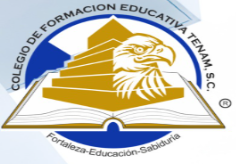

# Actividad ESTEREOVISION E IMÁGENES DE RANGO
## Universidad TENAM

**Docente:** DANIEL GONZÁLEZ SCARPULLI  
**Alumno:** Ismael Rufino Grajeda Marin

#### Disparidad por apareamiento basado en bordes

In [4]:
% Compatibilidad grafica con octave y jupiter  
graphics_toolkit('gnuplot');
set(0, 'defaultfigurevisible', 'off');
% paquete necesario para histeq
pkg load image;

ans = -73.077


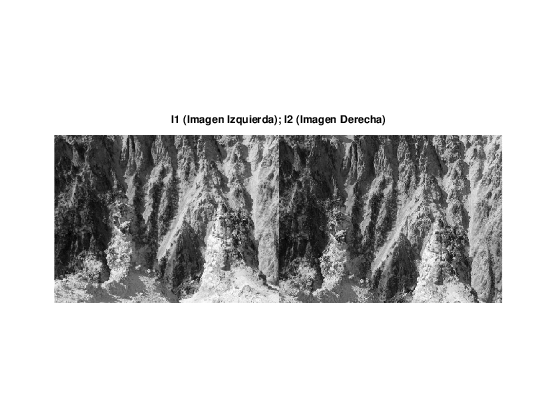

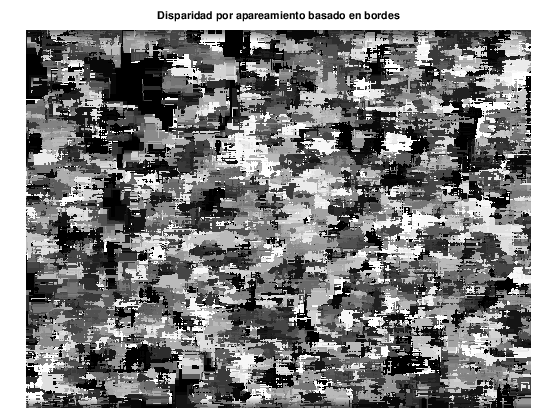

In [6]:
% Cargar paquete image
pkg load image;

% Cargar las imágenes estéreo
imagen1 = imread('img/3d1.jpg');
imagen2 = imread('img/3d2.jpg');

% Convertir las imágenes a escala de grises si es necesario
if size(imagen1, 3) > 1
 imagen1 = rgb2gray(imagen1);
end
if size(imagen2, 3) > 1
 imagen2 = rgb2gray(imagen2);
end

% Aplicar el operador Canny para detectar bordes en ambas imágenes
umbral = 0.1;
bordes1 = edge(imagen1, 'Canny', umbral);
bordes2 = edge(imagen2, 'Canny', umbral);

% Definir los parámetros de disparidad
ventana_busqueda = 11;
rango_disparidad = 50;

% Inicializar la matriz de disparidad
[filas, columnas] = size(imagen1);
disparidad = zeros(filas, columnas);

% Calcular la disparidad para cada píxel
for i = 1:filas
 for j = 1:columnas
     % Definir la ventana de búsqueda para el píxel actual
     fila_inicio = max(1, i - ventana_busqueda);
     fila_fin = min(filas, i + ventana_busqueda);
     col_inicio = max(1, j - ventana_busqueda);
     col_fin = min(columnas, j + ventana_busqueda);

     % Buscar el mejor apareamiento de bordes en la ventana de búsqueda
     mejor_disparidad = 0;
     mejor_similitud = Inf;
     for d = 0:rango_disparidad
         % Calcular la similitud de bordes en la ventana de búsqueda
         similitud = sum(sum(bordes1(fila_inicio:fila_fin, col_inicio:col_fin) & ...
         circshift(bordes2(fila_inicio:fila_fin, col_inicio:col_fin), [d, 0])));

         % Actualizar el mejor apareamiento si se encuentra una mejor similitud
         if similitud < mejor_similitud
             mejor_similitud = similitud;
             mejor_disparidad = d;
         end
     end

     % Asignar la disparidad al píxel actual
     disparidad(i, j) = mejor_disparidad;
 end
end

% Visualizar imágenes originales
figure
imshowpair(imagen1,imagen2,"montage")
title("I1 (Imagen Izquierda); I2 (Imagen Derecha)")

% Visualizar la disparidad resultante
figure
imshow(disparidad, []);
title('Disparidad por apareamiento basado en bordes');


%{ 
% Se utilizan las funciones 'detectSURFFeatures'
% para detectar puntos de interés (blobs) en las imágenes I1gray e I2gray.
blobs1 = detectSURFFeatures(imagen1,MetricThreshold=2000);
blobs2 = detectSURFFeatures(imagen2,MetricThreshold=2000);

% Se muestran las imágenes I1 eI2 y se superponen 
% los treinta puntos de interés (blobs) SURF más fuertes
figure
imshow(imagen1)
hold on
plot(selectStrongest(blobs1,30))
title("Treinta puntos de interés mas fuertes con SURF en I1")

figure
imshow(imagen2)
hold on
plot(selectStrongest(blobs2,30))
title("Treinta puntos de interés mas fuertes con SURF en I2")

% Calcular disparidad entre los puntos de interés usando la función 'disparity'
disparidadMaxima = 64; % Definir la disparidad máxima a buscar
disparidad_mapa = disparity(imagen1, imagen2, 'BlockSize', 15, 'DisparityRange', [0, disparidadMaxima], 'Method', 'SemiGlobal');

% Visualizar el mapa de disparidad
figure
imshow(disparidad_mapa, [0, disparidadMaxima]);
title('Mapa de Disparidad');
colorbar;
%}


ans = -73.598


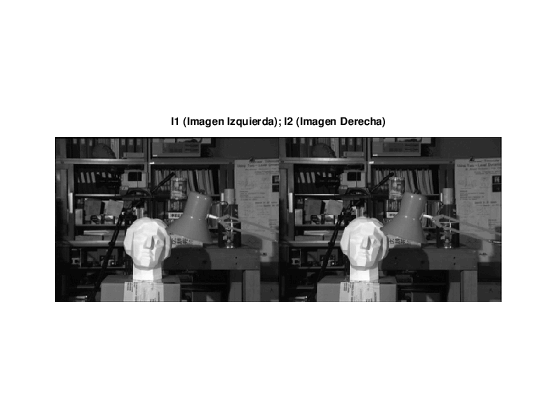

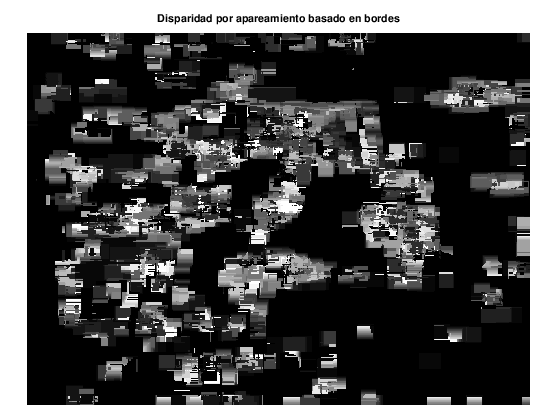

In [7]:
% Cargar paquete image
pkg load image;

% Cargar las imágenes estéreo
imagen1 = imread('img/disp_izq.jpg');
imagen2 = imread('img/disp_der.jpg');

% Convertir las imágenes a escala de grises si es necesario
if size(imagen1, 3) > 1
 imagen1 = rgb2gray(imagen1);
end
if size(imagen2, 3) > 1
 imagen2 = rgb2gray(imagen2);
end

% Aplicar el operador Canny para detectar bordes en ambas imágenes
umbral = 0.1;
bordes1 = edge(imagen1, 'Canny', umbral);
bordes2 = edge(imagen2, 'Canny', umbral);

% Definir los parámetros de disparidad
ventana_busqueda = 11;
rango_disparidad = 50;

% Inicializar la matriz de disparidad
[filas, columnas] = size(imagen1);
disparidad = zeros(filas, columnas);

% Calcular la disparidad para cada píxel
for i = 1:filas
 for j = 1:columnas
     % Definir la ventana de búsqueda para el píxel actual
     fila_inicio = max(1, i - ventana_busqueda);
     fila_fin = min(filas, i + ventana_busqueda);
     col_inicio = max(1, j - ventana_busqueda);
     col_fin = min(columnas, j + ventana_busqueda);

     % Buscar el mejor apareamiento de bordes en la ventana de búsqueda
     mejor_disparidad = 0;
     mejor_similitud = Inf;
     for d = 0:rango_disparidad
         % Calcular la similitud de bordes en la ventana de búsqueda
         similitud = sum(sum(bordes1(fila_inicio:fila_fin, col_inicio:col_fin) & ...
         circshift(bordes2(fila_inicio:fila_fin, col_inicio:col_fin), [d, 0])));

         % Actualizar el mejor apareamiento si se encuentra una mejor similitud
         if similitud < mejor_similitud
             mejor_similitud = similitud;
             mejor_disparidad = d;
         end
     end

     % Asignar la disparidad al píxel actual
     disparidad(i, j) = mejor_disparidad;
 end
end

% Visualizar imágenes originales
figure
imshowpair(imagen1,imagen2,"montage")
title("I1 (Imagen Izquierda); I2 (Imagen Derecha)")

% Visualizar la disparidad resultante
figure
imshow(disparidad, []);
title('Disparidad por apareamiento basado en bordes');


%{ 
% Se utilizan las funciones 'detectSURFFeatures'
% para detectar puntos de interés (blobs) en las imágenes I1gray e I2gray.
blobs1 = detectSURFFeatures(imagen1,MetricThreshold=2000);
blobs2 = detectSURFFeatures(imagen2,MetricThreshold=2000);

% Se muestran las imágenes I1 eI2 y se superponen 
% los treinta puntos de interés (blobs) SURF más fuertes
figure
imshow(imagen1)
hold on
plot(selectStrongest(blobs1,30))
title("Treinta puntos de interés mas fuertes con SURF en I1")

figure
imshow(imagen2)
hold on
plot(selectStrongest(blobs2,30))
title("Treinta puntos de interés mas fuertes con SURF en I2")

% Calcular disparidad entre los puntos de interés usando la función 'disparity'
disparidadMaxima = 64; % Definir la disparidad máxima a buscar
disparidad_mapa = disparity(imagen1, imagen2, 'BlockSize', 15, 'DisparityRange', [0, disparidadMaxima], 'Method', 'SemiGlobal');

% Visualizar el mapa de disparidad
figure
imshow(disparidad_mapa, [0, disparidadMaxima]);
title('Mapa de Disparidad');
colorbar;
%}
